# Goodreads Machine Learning - Group Project
------------
------------


## Decision/Actions Log : Executif Summary (updated sequentially)
1. clean raw data with 13 columns instead of 12 by concatenating authors column that spilled into average_rating column (fixed manually)
2. clean columns with leading/trailing spaces
3. clean publication_date column (2 errors found, fixed manually with isbn web search)
4. add a column fot publication_year
5. sanitize strings and add a column for clean_title, clean_authors, clean_publisher
6. add a column for the first author and the number of authors


## 0. Import libraries & Helper functions
----------

In [1]:
import re
import unicodedata
from typing import Any

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
def plot_distribution_with_mean(
    data,
    column,
    *,
    lower=0,
    upper=1500,
    title=None,
    xlabel=None,
    bins=40,
    color="#2a9d8f",
    mean_color="#e76f51",
    figsize=(9, 5),
    show_metrics=True,
):
    """Histogram + KDE with mean line, clipped to [lower, upper]."""
    series = data[column].dropna()
    series = series[(series >= lower) & (series <= upper)]

    col_mean = series.mean()
    col_std = series.std()

    plot_title = title or f"Distribution of {column} ({lower}–{upper})"
    plot_xlabel = xlabel or column

    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(series, bins=bins, kde=True, color=color, ax=ax)
    ax.axvline(
        col_mean,
        color=mean_color,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {col_mean:.3f}",
    )
    ax.set_xlim(lower, upper)
    ax.set_title(plot_title)
    ax.set_xlabel(plot_xlabel)
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if show_metrics:
        display(pd.DataFrame({
            "metric": ["mean", "standard_deviation", "minimum", "maximum", "count"],
            "value": [col_mean, col_std, series.min(), series.max(), len(series)],
        }))

    return fig, ax

In [3]:
def normalize_string(
    value: Any,
    *,
    lowercase: bool = True,
    strip_accents: bool = True,
    collapse_whitespace: bool = True,
    remove_suffixes: bool = False,
    remove_punctuation: bool = False,
) -> str | None:
    """
    Normalize a single string for fuzzy matching / grouping keys.
    Returns None for None/NaN. Non-strings are cast to str first.
    """
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    s = str(value).strip()
    if not s:
        return ""
    if lowercase:
        s = s.lower()
    if strip_accents:
        s = unicodedata.normalize("NFKD", s)
        s = "".join(c for c in s if not unicodedata.combining(c))
    if collapse_whitespace:
        s = re.sub(r"\s+", " ", s)
    if remove_suffixes:
        s = re.sub(
            r"\s+(jr\.?|sr\.?|iii|ii|iv)$",
            "",
            s,
            flags=re.IGNORECASE,
        ).strip()
    if remove_punctuation:
        s = re.sub(r"[^\w\s]", "", s)
        s = re.sub(r"\s+", " ", s).strip()
    return s

--------------------------------------
--------------------------------------
## 1. Loading Data
--------------------------------------
--------------------------------------

In [4]:
CSV_RAW_PATH = "../data/raw/books.csv"

In [5]:
df = pd.read_csv(CSV_RAW_PATH, index_col="bookID", on_bad_lines='warn')


C:\Users\veron\AppData\Local\Temp\ipykernel_28828\1247233899.py:1: ParserWarning: Skipping line 3350: expected 12 fields, saw 13
Skipping line 4704: expected 12 fields, saw 13
Skipping line 5879: expected 12 fields, saw 13
Skipping line 8981: expected 12 fields, saw 13

  df = pd.read_csv(CSV_RAW_PATH, index_col="bookID", on_bad_lines='warn')


Upon inspection, the 4 errors came from the fact that the author string contained a comma "," which was interpreted as a new column and spilled the author name into the nex column when creating the .csv, thus resulting in 13 columns instead of 12

In [6]:
# the 4 errors were manualy fixed (joining the 2 columns with "," for these 4 error rows)
CSV_CLEANED_PATH = "../data/processed/books-hugo.csv" 
df = pd.read_csv(CSV_CLEANED_PATH, on_bad_lines='warn')

------------------------------------------
------------------------------------------
## 2. EDA & Cleaning Data
------------------------------------------
------------------------------------------

In [7]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11127 non-null  int64  
 1   title               11127 non-null  object 
 2   authors             11127 non-null  object 
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  object 
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  object 
 7     num_pages         11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  object 
 11  publisher           11127 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


### **observations :**
- It looks like there is a leading space for the " num_pages" column name
- isbn13 as int64 seems like the wrong type for and identifier, but not a big deal because we will probably drop these columns
- publication_date as string is not ideal, should be parsed to date

In [9]:
# check if bookID, ISBN, ISBN13 are all uniques
cols = ["bookID", "isbn", "isbn13"]
{col: df[col].is_unique for col in cols}

{'bookID': True, 'isbn': True, 'isbn13': True}

**Set index**

In [10]:
# since all are unique, we can select any for indexing, lets select bookID
df.set_index("bookID", inplace=True)

**Fix trailing/leading spaces**

In [11]:
# fix column names
df.columns = df.columns.str.strip()

In [12]:
# test if any of the values contains leading/trailing spaces
for col in df.columns:
    if df[col].dtype == "str":
        has_spaces = df[col].dropna().ne(df[col].dropna().str.strip()).any()
        if has_spaces:
            print(f"!! Leading/trailing spaces detected in column: {col}")
        else:
            print(f"no spaces detected on column : {col}")



copy dataframe for cleaning

In [13]:
df_clean = df.copy()

In [14]:
# fix spaces in titles
df_clean["title"] = df_clean["title"].str.strip()

**Convert publication date to datetime**

In [15]:
# fix publication_date, passing format to parse
pub_raw = df_clean["publication_date"].copy()
df_clean["publication_date"] = pd.to_datetime(
    df_clean["publication_date"],
    format="%m/%d/%Y",
    errors="coerce", # if the format is not correct, set to NaT
)
# check original values where the conversion failed
pub_raw.loc[df_clean["publication_date"].isna()]

bookID
31373    11/31/2000
45531     6/31/1982
Name: publication_date, dtype: object

2 dates did not convert properly : these dates are impossible, lets check ISBN code and look for the information on the internet since there is only 2 books with invalid dates

In [16]:
# check ISBN13 code
df_clean.loc[df_clean.publication_date.isna(), ["isbn", "isbn13", "title"]]

,isbn,isbn13,title
bookID,,,
31373,0553575104,9780553575101,In Pursuit of the Proper Sinner (Inspector Lyn...
45531,2070323285,9782070323289,Montaillou village occitan de 1294 à 1324


According to current goodreads.com: 
- *In Pursuit of the Proper Sinner* was puplished in October 31st, 2000
- *Montaillou  village occitan de 1294 à 1324* was published in June 30, 1982

One date is wrong by 1 day, the other by 1 month. 

These errors could be isolated, or might be a symptom of a larger issue with dates. Some of the parsable date might still be wrong. Goodreads.com does not provide a public API to check the data programmatically (an unofficial one exist on Apify), but there are other options to check the publishing date with Open Library or Google Books API.  

Lets apply a target fix:

In [17]:
# fix the dates by index
df_clean.loc[31373, "publication_date"] = pd.to_datetime("2000-10-31")
df_clean.loc[45531, "publication_date"] = pd.to_datetime("1982-06-30")

Lets take the opportunity to add a new column for year of publication as it will be more usefull that the exact date

In [18]:
df_clean["publication_year"] = df_clean["publication_date"].dt.year

**String Sanitization : apply normalization function**

In [19]:
df_clean["title"] = df_clean["title"].apply(normalize_string)
df_clean["authors"] = df_clean["authors"].apply(normalize_string)
df_clean["publisher"] = df_clean["publisher"].apply(normalize_string)

**Creating new colums for *Authors* : inspection of the data show that authors are separated by "/"**

In [20]:
# check what is the maximum number of authors for one book
n_authors = df_clean["authors"].str.split("/").str.len()
print("max number of authors for one book :", n_authors.max())

max number of authors for one book : 51


51 authors for one book !

In [21]:
cols = ["title", "authors"]
df_clean.loc[n_authors == n_authors.max(), cols]

,title,authors
bookID,,
39690,good poems for hard times,garrison keillor/charles bukowski/robert burns...


To avoid empty data, and because the first author is usually the main one (confirmed below), lets add a column for the first author only, and one column with the number of authors

In [22]:
# creating new columns
df_clean["first_author"] = df_clean["authors"].str.split(
    "/").str[0].str.strip()
df_clean["n_authors"] = n_authors

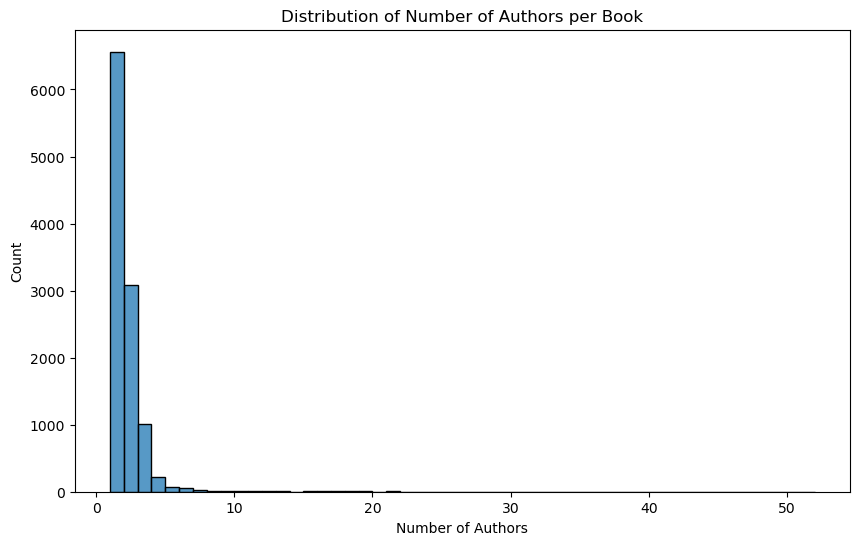

In [23]:
# plot showing the number of authors per book
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["n_authors"], bins=range(1, n_authors.max() + 2))
plt.title("Distribution of Number of Authors per Book")
plt.xlabel("Number of Authors")
plt.ylabel("Count")
plt.show()

It looks like books with more than 10 authors are rare, we might want to remove them from the dataset or use a logaritmic scale later on.

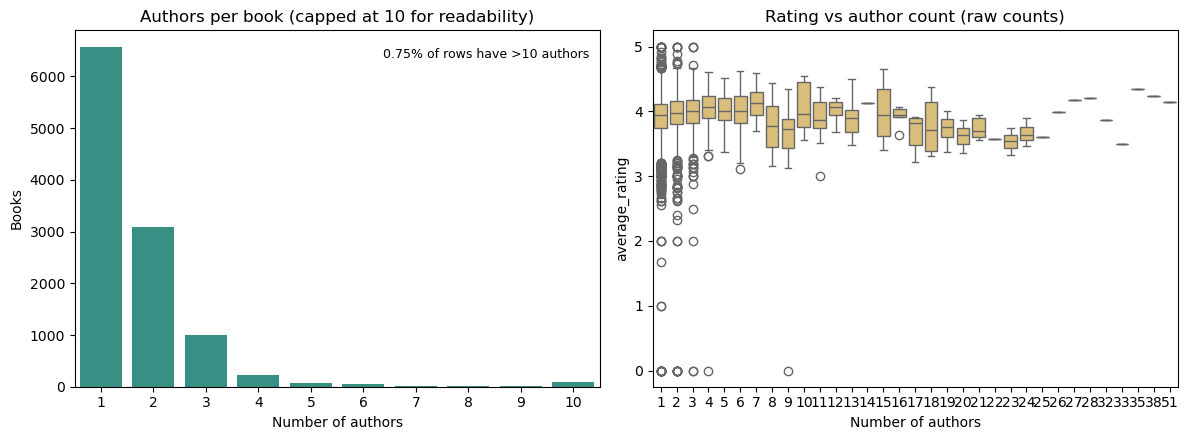

In [24]:
# Authors per book — most books have one author; tail is long
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(
    data=df_clean.assign(author_bucket=df_clean["n_authors"].clip(upper=10).astype(int)),
    x="author_bucket",
    color="#2a9d8f",
    ax=axes[0],
)
axes[0].set_title("Authors per book (capped at 10 for readability)")
axes[0].set_xlabel("Number of authors")
axes[0].set_ylabel("Books")

high_author_share = (df_clean["n_authors"] > 10).mean()
axes[0].text(
    0.98,
    0.95,
    f"{high_author_share:.2%} of rows have >10 authors",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
)

sns.boxplot(data=df_clean, x="n_authors", y="average_rating",
            color="#e9c46a", ax=axes[1])
axes[1].set_title("Rating vs author count (raw counts)")
axes[1].set_xlabel("Number of authors")
plt.tight_layout()
plt.show()

## Looking for blank/empty/null/bad data


In [25]:
df_clean.describe()

,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,publication_date,publication_year,n_authors
count,11127.000000,1.112700e+04,11127.000000,1.112700e+04,11127.000000,11127,11127.000000,11127.000000
mean,3.933631,9.759888e+12,336.376921,1.793641e+04,541.854498,2000-08-27 22:58:00.614720896,2000.167520,1.729487
min,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000,1900-01-01 00:00:00,1900.000000,1.000000
25%,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000,1998-07-16 12:00:00,1998.000000,1.000000
50%,3.960000,9.780586e+12,299.000000,7.450000e+02,46.000000,2003-03-01 00:00:00,2003.000000,1.000000
75%,4.135000,9.780873e+12,416.000000,4.993500e+03,237.500000,2005-09-30 00:00:00,2005.000000,2.000000
max,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000,2020-03-31 00:00:00,2020.000000,51.000000
std,0.352445,4.428964e+11,241.127305,1.124794e+05,2576.176608,NaN,8.248836,1.819852


At first glance, we can see that there are rows with num_pages and text_reviews_count equal to 0  
➜ should be investigated and cleaned

In [26]:
df_clean.isna().sum()

title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
publication_year      0
first_author          0
n_authors             0
dtype: int64

Check for other bad/empty data :

In [27]:
# check for bad data
bad_inputs = ["", "nan", "None", "N/A", "null", "-"]
bad_results = {}
for col in df.columns:
    mask = df_clean[col].astype(str).str.strip().str.lower().isin(bad_inputs)
    bad_results[col] = int(mask.sum())
bad_results

{'title': 0,
 'authors': 0,
 'average_rating': 0,
 'isbn': 0,
 'isbn13': 0,
 'language_code': 0,
 'num_pages': 0,
 'ratings_count': 0,
 'text_reviews_count': 0,
 'publication_date': 0,
 'publisher': 0}

➜ no strictly missing values
But visual analysis show that multiple entries have "NOT A BOOK" as authors

In [28]:
# count the number of books with "NOT A BOOK" as authors
print("number of books with 'NOT A BOOK' as authors :", (df_clean["authors"] == "NOT A BOOK".lower()).sum())

# drop these rows
#df_clean = df_clean[df_clean["authors"] != "NOT A BOOK"]

number of books with 'NOT A BOOK' as authors : 5


In [29]:
df_clean.loc[df_clean["authors"] == "NOT A BOOK".lower(),:]

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,publication_year,first_author,n_authors
bookID,,,,,,,,,,,,,,
3593,murder by moonlight & other mysteries (new adv...,not a book,4.00,0743564677,9780743564670,eng,0,7,2,2006-10-03,simon schuster audio,2006,not a book,1
3599,the unfortunate tobacconist & other mysteries ...,not a book,3.50,074353395X,9780743533959,eng,0,12,1,2003-10-01,simon & schuster audio,2003,not a book,1
19786,the goon show volume 4: my knees have fallen off!,not a book,5.00,0563388692,9780563388692,eng,2,3,0,1996-04-01,bbc physical audio,1996,not a book,1
19787,the goon show: moriarty where are you?,not a book,4.43,0563388544,9780563388548,eng,2,0,0,2005-03-30,bbc physical audio,2005,not a book,1
19788,the goon show volume 11: he's fallen in the wa...,not a book,5.00,0563388323,9780563388326,eng,2,2,0,1995-10-02,bbc physical audio,1995,not a book,1


This looks like audio books or podcasts

# Zero values

In [30]:
print("num_pages zero count :", (df_clean["num_pages"] == 0).sum())
print("ratings_count zero count :", (df_clean["ratings_count"] == 0).sum())
print("text_reviews_count zero count :", (df_clean["text_reviews_count"] == 0).sum())

num_pages zero count : 76
ratings_count zero count : 81
text_reviews_count zero count : 625


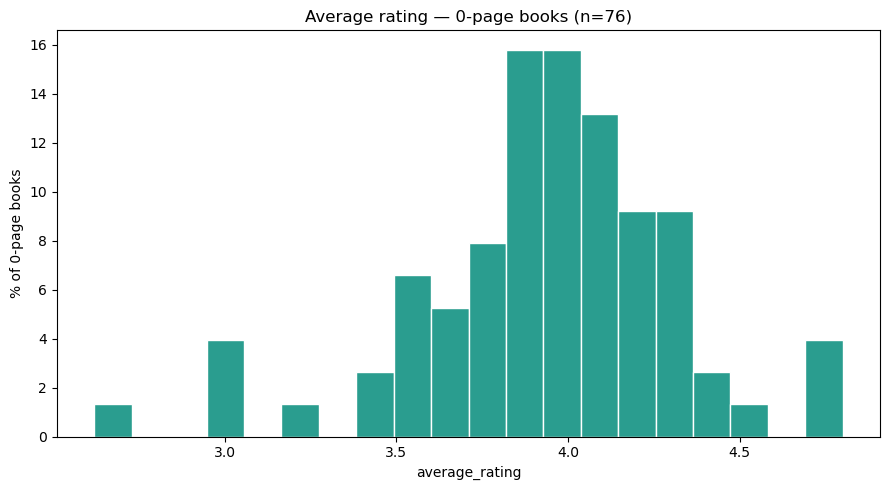

In [31]:
zero_pages = df_clean.loc[df_clean["num_pages"] == 0, "average_rating"]
weights = np.ones(len(zero_pages)) / len(zero_pages) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(zero_pages, bins=20, weights=weights,
        color="#2a9d8f", edgecolor="white")
ax.set_title(f"Average rating — 0-page books (n={len(zero_pages)})")
ax.set_xlabel("average_rating")
ax.set_ylabel("% of 0-page books")
plt.tight_layout()
plt.show()

In [32]:
zero_pages = df_clean.loc[df_clean["num_pages"] == 0, "average_rating"]

bins = [0, 1, 2, 3, 4, 4.5, 5.01]
labels = ["0–1", "1–2", "2–3", "3–4", "4–4.5", "4.5–5"]


def rating_dist_pct(series):
    return (
        pd.cut(series, bins=bins, labels=labels, right=False)
        .value_counts(normalize=True)
        .reindex(labels)  # keep all bins, even 0%
        .mul(100)
        .round(2)
    )


compare = pd.DataFrame({
    "All books": rating_dist_pct(df_clean["average_rating"]),
    "0 pages": rating_dist_pct(zero_pages),
})

compare

,All books,0 pages
average_rating,,
0–1,0.23,0.00
1–2,0.03,0.00
2–3,0.50,2.63
3–4,54.71,52.63
4–4.5,42.46,39.47
4.5–5,2.07,5.26


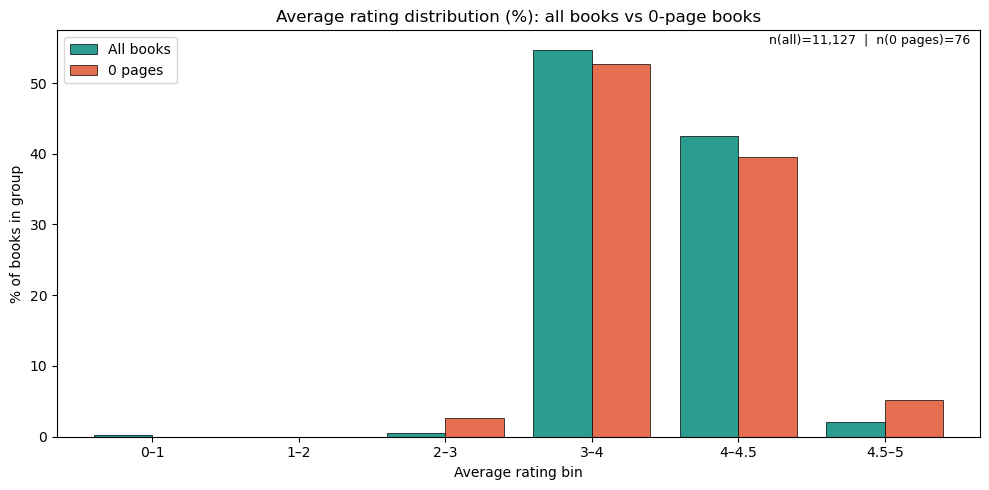

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

compare.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=["#2a9d8f", "#e76f51"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Average rating distribution (%): all books vs 0-page books")
ax.set_xlabel("Average rating bin")
ax.set_ylabel("% of books in group")
ax.legend(title="")
ax.set_xticklabels(labels, rotation=0)

# optional: show n in legend or subtitle
n_all = len(df_clean)
n_zero = len(zero_pages)
ax.text(
    0.99, 0.99,
    f"n(all)={n_all:,}  |  n(0 pages)={n_zero}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [34]:
zero_reviews = df_clean.loc[df_clean["text_reviews_count"]
                            == 0, "average_rating"]

bins = [0, 1, 2, 3, 4, 4.5, 5.01]
labels = ["0–1", "1–2", "2–3", "3–4", "4–4.5", "4.5–5"]


def rating_dist_pct(series):
    return (
        pd.cut(series, bins=bins, labels=labels, right=False)
        .value_counts(normalize=True)
        .reindex(labels)
        .mul(100)
        .round(2)
    )


compare_reviews = pd.DataFrame({
    "All books": rating_dist_pct(df_clean["average_rating"]),
    "0 text reviews": rating_dist_pct(zero_reviews),
})

compare_reviews

,All books,0 text reviews
average_rating,,
0–1,0.23,4.00
1–2,0.03,0.32
2–3,0.50,2.56
3–4,54.71,49.12
4–4.5,42.46,35.04
4.5–5,2.07,8.96


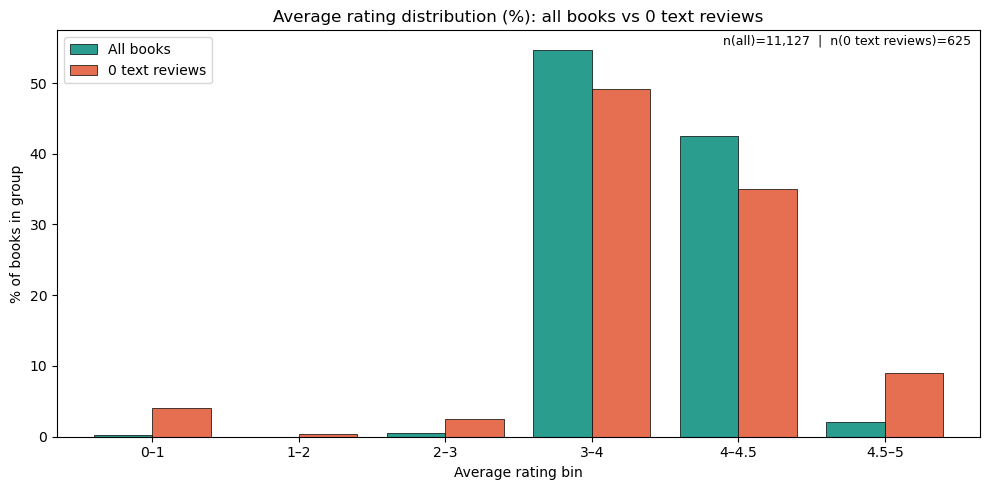

In [35]:
n_all = len(df_clean)
n_zero_rev = len(zero_reviews)

fig, ax = plt.subplots(figsize=(10, 5))

compare_reviews.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=["#2a9d8f", "#e76f51"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Average rating distribution (%): all books vs 0 text reviews")
ax.set_xlabel("Average rating bin")
ax.set_ylabel("% of books in group")
ax.legend(title="")
ax.set_xticklabels(labels, rotation=0)
ax.text(
    0.99, 0.99,
    f"n(all)={n_all:,}  |  n(0 text reviews)={n_zero_rev}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=9,
)

plt.tight_layout()
plt.show()

**What to do with these : further analysis needed**

num_pages = 0 ➜ encode average/median?  
ratings_count = 0 ➜ drop ?
text_reviews_count = 0 ➜ could be an actual signal, keep ?

In [36]:
# drop rows with ratings_count = 0
df_clean = df_clean[df_clean["ratings_count"] > 0]

# Feature Engineering : collections, series, audiobooks
Some titles either multiple books from a collection, or are one volume that is part of a collection, this is usually indicated by a parenthetical note after the title.

In [37]:
# Adding a boolean column to identify wether or not a record a collection, part of a series or an audio book. 
# The identifiers for series are "#[number]" / "Volume [number]" / "Vol. [number]" / "Books [number]" / "Part [number] /"Tome [number]"
REGEX_FLAGS = re.IGNORECASE | re.VERBOSE

NUM = r"(?:\d+(?:\.\d+)?|[ivxlcdm]+|one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve)"
NUM_RANGE = rf"{NUM}(?:\s*(?:[-\u2013\u2014,/&]|and)\s*{NUM})*"

collection_pattern = r"""
\b(?:box(?:ed)?\s+set|omnibus|antholog(?:y|ies)|collection)\b
|
\b(?:complete|collected|selected|essential|major)\s+
(?:works|novels|stories|short\s+stories|poems|poetry|plays|writings|letters|essays|tragedies|adventures|memoirs)\b
|
\b\d+\s*(?:book|volume)s?\s+(?:box(?:ed)?\s+set|set|collection)\b
|
\b(?:\d+\s+)?volumes?\s+set\b
"""

series_pattern = rf"""
\([^)]*(?:\#\s*{NUM_RANGE}|\b(?:vol(?:ume)?s?\.?|books?|part|tome)\s+{NUM_RANGE})[^)]*\)
|
(?<!\w)\#\s*{NUM_RANGE}\b
|
\b(?:vol(?:ume)?s?\.?|part|tome)\s+{NUM_RANGE}\b
"""

# Optional broad add-on, but noisier:
book_number_pattern = rf"\bbooks?\s+{NUM_RANGE}\b"

audio_pattern = r"""
audio(?:books?|go|text)?\b
|
\bcassettes?\b
|
\bcd\s*audio\b
|
\baudio\s*cd\b
|
\blistening\s+library\b
"""

title = df_clean["title"].fillna("")
title_publisher = (
    df_clean["title"].fillna("") + " " + df_clean["publisher"].fillna("")
)

df_clean["is_collection"] = title.str.contains(
    collection_pattern, regex=True, flags=REGEX_FLAGS, na=False)
df_clean["is_series"] = title.str.contains(
    series_pattern, regex=True, flags=REGEX_FLAGS, na=False)
df_clean["is_audio"] = title_publisher.str.contains(
    audio_pattern, regex=True, flags=REGEX_FLAGS, na=False)

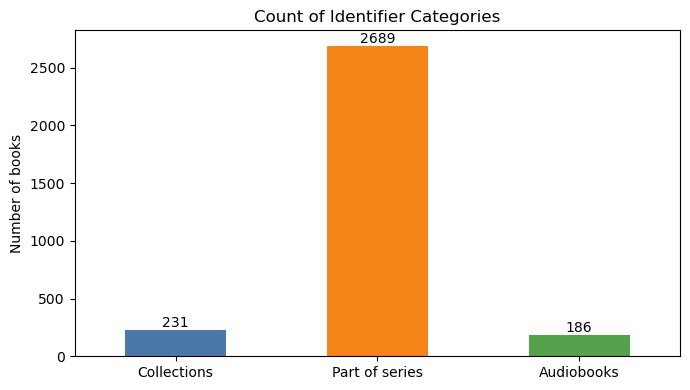

In [38]:
# graph to show the number of books that are collection, series and audio (in the same graph)
identifier_counts = (
    df_clean[["is_collection", "is_series", "is_audio"]]
    .sum()
    .rename({
        "is_collection": "Collections",
        "is_series": "Part of series",
        "is_audio": "Audiobooks",
    })
)

ax = identifier_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color=["#4C78A8", "#F58518", "#54A24B"],
)

ax.set_title("Count of Identifier Categories")
ax.set_ylabel("Number of books")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

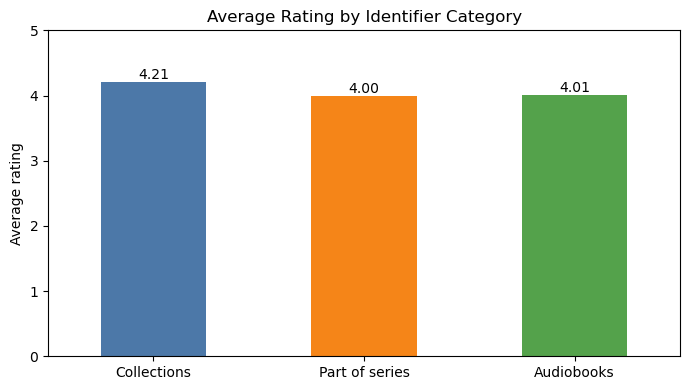

In [39]:
rating_means = pd.Series({
    "Collections": df_clean.loc[df_clean["is_collection"], "average_rating"].mean(),
    "Part of series": df_clean.loc[df_clean["is_series"], "average_rating"].mean(),
    "Audiobooks": df_clean.loc[df_clean["is_audio"], "average_rating"].mean(),
})

ax = rating_means.plot(
    kind="bar",
    figsize=(7, 4),
    color=["#4C78A8", "#F58518", "#54A24B"],
)

ax.set_title("Average Rating by Identifier Category")
ax.set_ylabel("Average rating")
ax.set_xlabel("")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

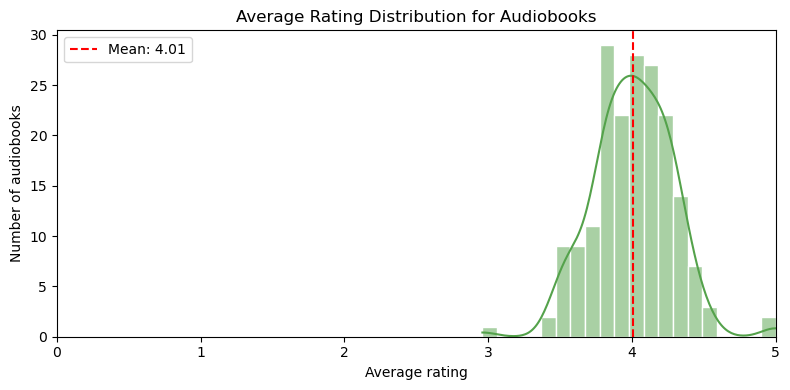

In [40]:
audio_ratings = df_clean.loc[
    df_clean["is_audio"], "average_rating"
].dropna()

plt.figure(figsize=(8, 4))

sns.histplot(
    audio_ratings,
    bins=20,
    kde=True,
    color="#54A24B",
    edgecolor="white"
)

plt.axvline(
    audio_ratings.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {audio_ratings.mean():.2f}"
)

plt.title("Average Rating Distribution for Audiobooks")
plt.xlabel("Average rating")
plt.ylabel("Number of audiobooks")
plt.xlim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()

## Looking for silent duplicates
------------------------

We already established that there are no strict duplicates, since bookID, isbn and isbn13 are all uniques

**Title duplicates**

In [41]:
# number of duplicated titles
print("number of duplicated titles :",(df_clean["title"].value_counts() > 1).sum())

number of duplicated titles : 531


The clean "title" is a sanitized version of the title, it is more reliable to use it for duplicate detection but we need to check if there are some cases where the cleaned title is the same but the raw title is actually different on purpose.



There are a few duplicated titles, but they might have different authors

In [42]:
#  duplicated titles & authors
dup_counts = df_clean[["title", "authors"]].value_counts()
print("number of duplicated titles & authors :",(dup_counts > 1).sum())
# (df[["title","authors"]].value_counts()>1).sum()

number of duplicated titles & authors : 289


In [43]:
# check if there exist books with same title and authors, but different ratings
print("number of books with same title and authors, but different ratings :", (df_clean.groupby(["title","authors"])["average_rating"].nunique() > 1).sum())

number of books with same title and authors, but different ratings : 0


In [44]:
# check if there exist books with same title and authors, but different ratings
print("number of books with same title and authors, but different ratings :", (df_clean.groupby(["title", "authors"])["average_rating"].nunique() > 1).sum())

number of books with same title and authors, but different ratings : 0


Good news, duplicated books (by title & authors) all have the same ratings

In [45]:
# number of book with same title but different authors
df_same_title_not_authors = df_clean.groupby(
    ["title"])["authors"].nunique() > 1
print("number of books with same title but different authors :",df_same_title_not_authors.sum())

number of books with same title but different authors : 304


In [46]:
df_clean["title"].value_counts()

title
the iliad                                         9
the brothers karamazov                            9
the odyssey                                       8
anna karenina                                     8
'salem's lot                                      8
                                                 ..
sanctuary (dragon jousters #3)                    1
fortune's fool (five hundred kingdoms #3)         1
the fairy godmother (five hundred kingdoms #1)    1
the wizard of london (elemental masters #4)       1
las aventuras de tom sawyer                       1
Name: count, Length: 10213, dtype: int64

In [47]:
df_clean[df_clean["title"] == "the iliad"][:]

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,publication_year,first_author,n_authors,is_collection,is_series,is_audio
bookID,,,,,,,,,,,,,,,,,
1371,the iliad,homer/robert fagles/bernard knox,3.86,0140275363,9780140275360,eng,683,288792,3423,1999-04-29,penguin classics,1999,homer,3,False,False,False
1374,the iliad,homer/robert fitzgerald/andrew ford,3.86,0374529051,9780374529055,en-US,588,692,81,2004-04-03,farrar straus and giroux,2004,homer,3,False,False,False
1376,the iliad,homer/e.v. rieu/peter jones/d.c.h. rieu,3.86,0140447946,9780140447941,eng,462,1919,118,2003-01-30,penguin classics,2003,homer,4,False,False,False
1377,the iliad,homer/w.h.d. rouse,3.86,0451527372,9780451527370,en-US,312,158,15,1999-08-01,signet classics,1999,homer,2,False,False,False
1796,the iliad,homer/robert fitzgerald,3.86,1857150600,9781857150605,eng,594,30,2,1992-03-19,everyman,1992,homer,2,False,False,False
12254,the iliad,homer/robert fagles/derek jacobi,3.86,0143059289,9780143059288,eng,8,42,7,2006-06-15,penguin-highbridge,2006,homer,3,False,False,False
22221,the iliad,homer,3.86,0471377589,9780471377580,eng,150,3834,134,1999-10-28,john wiley & sons,1999,homer,1,False,False,False
32780,the iliad,homer/andrew lang,3.86,1904633382,9781904633389,eng,542,64,8,2011-09-01,collector's library,2011,homer,2,False,False,False
32782,the iliad,homer/victor g. ambrus/nick mccarty,3.86,0753453215,9780753453216,eng,95,8,3,2000-09-15,kingfisher,2000,homer,3,False,False,False


From this example, we can infer that even though the authors are differents, the first author is the same.
We might use this information to merge the books with the same title but different authors.

In [48]:
# number for books with same title but different first author
df_same_title_not_1st_author = df_clean.groupby(
    ["title"])["first_author"].nunique() > 1
print("number of books with same title but different first author :",df_same_title_not_1st_author.sum())

number of books with same title but different first author : 64


In [49]:
print("number of books with same title and first_author but different average rating :",
      (df_clean.groupby(["title", "first_author"])
       ["average_rating"].nunique() > 1).sum()
)

number of books with same title and first_author but different average rating : 5


In [50]:

(
    df_clean.groupby(["title", "authors"], as_index=False)
    .agg(
        n_copies=("title", "size"),
        language_code=("language_code", list),
        num_pages=("num_pages", list),
        publisher=("publisher", list),
        publication_year=("publication_year", list),
        average_rating=("average_rating", list),
        ratings_count=("ratings_count", list),
        text_reviews_count=("text_reviews_count", list),
    )
    .query("n_copies > 1")
    .nlargest(20, "n_copies")
)

,title,authors,n_copies,language_code,num_pages,publisher,publication_year,average_rating,ratings_count,text_reviews_count
4,'salem's lot,stephen king,5,"[eng, en-US, eng, eng, eng]","[405, 427, 586, 817, 427]","[doubleday, signet, hodder & stoughton ltd, si...","[1975, 1979, 2010, 1976, 1976]","[4.02, 4.02, 4.02, 4.02, 4.02]","[1039, 178, 25, 18, 186]","[130, 35, 6, 3, 22]"
4634,memoirs of a geisha,arthur golden,5,"[eng, eng, en-US, eng, eng]","[503, 434, 497, 497, 452]","[vintage books usa, random house large print p...","[2005, 2005, 2005, 1998, 2000]","[4.11, 4.11, 4.11, 4.11, 4.11]","[280309, 1301083, 2122, 4189, 57]","[3703, 19296, 256, 462, 8]"
5271,one hundred years of solitude,gabriel garcia marquez/gregory rabassa,5,"[eng, eng, eng, eng, eng]","[458, 417, 448, 560, 422]","[harper perennial, turtleback books, harper pe...","[2004, 2006, 2006, 2004, 1972]","[4.07, 4.07, 4.07, 4.07, 4.07]","[3437, 90, 1608, 130, 640]","[316, 5, 212, 5, 65]"
7492,the curious incident of the dog in the night-time,mark haddon,5,"[eng, eng, eng, eng, eng]","[226, 272, 268, 240, 6]","[vintage, vintage, red fox, doubleday canada, ...","[2004, 2004, 2004, 2006, 2006]","[3.88, 3.88, 3.88, 3.88, 3.88]","[1054308, 16588, 6124, 34, 614]","[35537, 1606, 754, 6, 119]"
6609,sula,toni morrison,4,"[eng, eng, eng, eng]","[174, 174, 174, 189]","[plume books, vintage international, plume, vi...","[2002, 2004, 1987, 2005]","[3.93, 3.93, 3.93, 3.93]","[47998, 3552, 457, 709]","[2479, 361, 49, 94]"
7721,the enemy (jack reacher #8),lee child/dick hill,4,"[eng, eng, eng, eng]","[14, 14, 14, 14]","[brilliance audio, brilliance audio, brillianc...","[2004, 2004, 2004, 2004]","[4.16, 4.16, 4.16, 4.16]","[178, 4, 3, 1]","[35, 0, 2, 0]"
9082,the scarlet letter,nathaniel hawthorne,4,"[eng, eng, eng, eng]","[400, 224, 538, 553]","[simon & schuster, ann arbor media, kaplan, ka...","[2004, 2006, 2005, 2006]","[3.4, 3.4, 3.4, 3.4]","[1373, 109, 534, 23]","[68, 8, 11, 4]"
9949,tripwire (jack reacher #3),lee child/dick hill,4,"[eng, en-US, eng, eng]","[3, 14, 14, 14]","[nova audio books, brilliance audio, brillianc...","[1999, 2004, 2004, 2004]","[4.09, 4.09, 4.09, 4.09]","[16, 3, 11, 18]","[3, 1, 1, 4]"
10382,white teeth,zadie smith,4,"[eng, eng, eng, en-GB]","[448, 542, 448, 542]","[vintage, penguin books, turtleback books, pen...","[2001, 2001, 2001, 2000]","[3.77, 3.77, 3.77, 3.77]","[102370, 4202, 81, 1265]","[5677, 406, 11, 142]"
336,a tale of two cities,charles dickens/gillen d'arcy wood,3,"[eng, en-US, en-GB]","[409, 429, 409]","[barnes & noble classics, barnes noble classic...","[2004, 2003, 2004]","[3.84, 3.84, 3.84]","[1343, 730, 301]","[183, 88, 44]"


As seen earlier, there are no truly duplicated rows, but some of the rows only differ by publisher or language code : average_rating is the same when title & authors are the same.

## Analysis : Average Rating (Target)
-----------

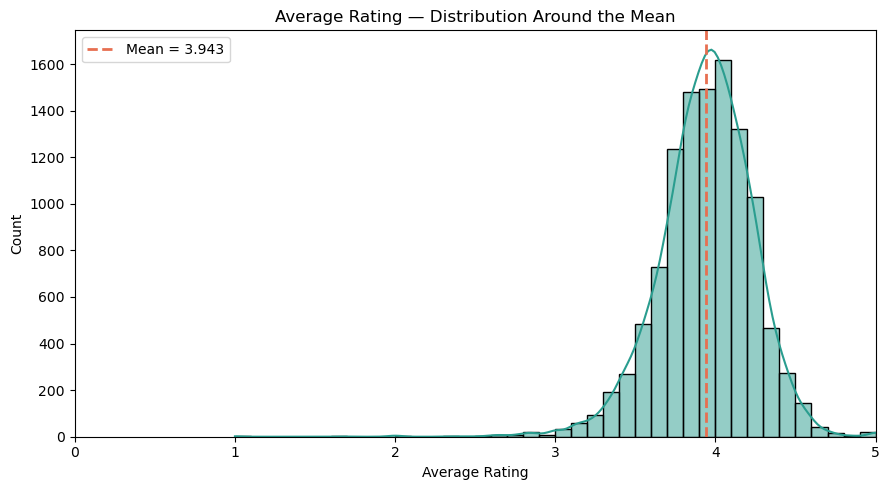

,metric,value
0,mean,3.943134
1,standard_deviation,0.295213
2,minimum,1.000000
3,maximum,5.000000
4,count,11046.000000


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Average Rating — Distribution Around the Mean'}, xlabel='Average Rating', ylabel='Count'>)

In [51]:
plot_distribution_with_mean(
    df_clean,
    column="average_rating",
    lower=0,
    upper=df_clean["average_rating"].max(),
    title="Average Rating — Distribution Around the Mean",
    xlabel="Average Rating",
)

**Interpretation**  
- distribution is heavily centered around the average : 3.93  
- a few books appear with average rating being zero

In [52]:
print("average_rating negative count :",(df_clean["average_rating"] < 0).sum())

average_rating negative count : 0


## Analysis : Ratings Count
-----------

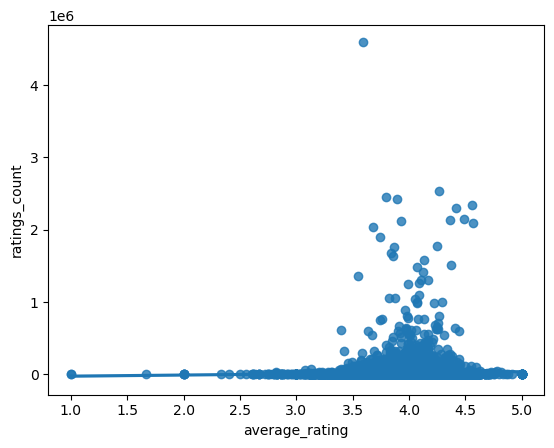

In [53]:
# correlation between average_rating and ratings_count
sns.regplot(x="average_rating", y="ratings_count", data=df_clean)
plt.show()

,rating_support_band,books,mean_rating,median_rating,rating_std,median_ratings_count,share_of_df_clean
0,1,76,3.810263,3.920,0.752528,1.0,0.006880
1,2,71,3.946901,3.960,0.635964,2.0,0.006428
2,3,82,3.807073,3.970,0.574917,3.0,0.007424
3,4,71,3.917887,4.000,0.502687,4.0,0.006428
4,5,61,3.886557,3.890,0.436650,5.0,0.005522
5,6,57,3.921228,3.970,0.436406,6.0,0.005160
6,7,56,3.875179,3.870,0.302005,7.0,0.005070
7,8,59,3.901186,3.970,0.463454,8.0,0.005341
8,9,60,3.910167,3.945,0.394880,9.0,0.005432
9,10-25,622,3.914260,3.940,0.340292,16.0,0.056310


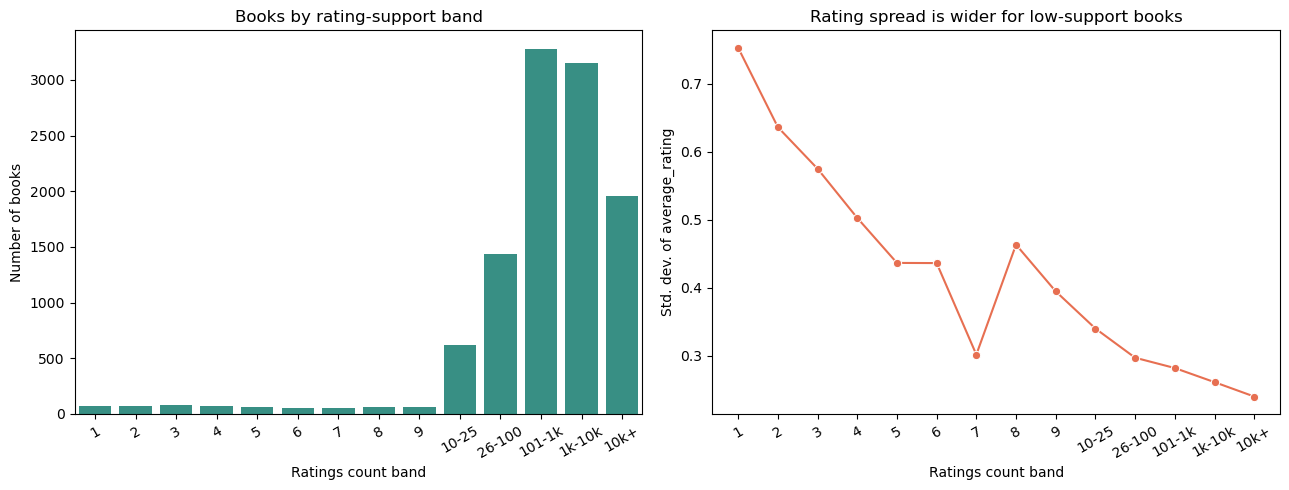

In [54]:
support_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 25, 100, 1_000, 10_000, np.inf]
support_labels = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10-25", "26-100", "101-1k", "1k-10k", "10k+"]
df_clean["rating_support_band"] = pd.cut(
    df_clean["ratings_count"],
    bins=support_bins,
    labels=support_labels,
    include_lowest=True,
)

support_table = (
    df_clean.groupby("rating_support_band", observed=True)
    .agg(
        books=("average_rating", "size"),
        mean_rating=("average_rating", "mean"),
        median_rating=("average_rating", "median"),
        rating_std=("average_rating", "std"),
        median_ratings_count=("ratings_count", "median"),
    )
    .reset_index()
)
support_table["share_of_df_clean"] = support_table["books"] / len(df_clean)
display(support_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=support_table,
    x="rating_support_band",
    y="books",
    color="#2a9d8f",
    ax=axes[0],
)
axes[0].set_title("Books by rating-support band")
axes[0].set_xlabel("Ratings count band")
axes[0].set_ylabel("Number of books")
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(
    data=support_table,
    x="rating_support_band",
    y="rating_std",
    marker="o",
    color="#e76f51",
    ax=axes[1],
)
axes[1].set_title("Rating spread is wider for low-support books")
axes[1].set_xlabel("Ratings count band")
axes[1].set_ylabel("Std. dev. of average_rating")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Analysis : Number of pages
-----------

Lets decide arbitrarily how many pages a book needs to have to be considered a real book

In [55]:
MIN_PAGES_COUNT = 5
MAX_PAGES_COUNT = 3000

In [56]:
print(
    f'books with less than {MIN_PAGES_COUNT} pages : {(df_clean["num_pages"]<MIN_PAGES_COUNT).sum()}\n'
    f'books with more than {MAX_PAGES_COUNT} pages : {(df_clean["num_pages"]>MAX_PAGES_COUNT).sum()}\n'
    f'books with zero pages : {(df_clean["num_pages"] == 0).sum()}'
)
 

books with less than 5 pages : 129
books with more than 3000 pages : 5
books with zero pages : 75


In [57]:
df_clean.loc[df_clean["num_pages"]>MAX_PAGES_COUNT,["title","num_pages", "average_rating"]]

,title,num_pages,average_rating
bookID,,,
10,harry potter collection (harry potter #1-6),3342,4.73
24520,the complete aubrey/maturin novels (5 volumes),6576,4.70
25587,the second world war,4736,4.45
25709,summa theologica 5 vols,3020,4.12
44613,remembrance of things past (boxed set),3400,4.34


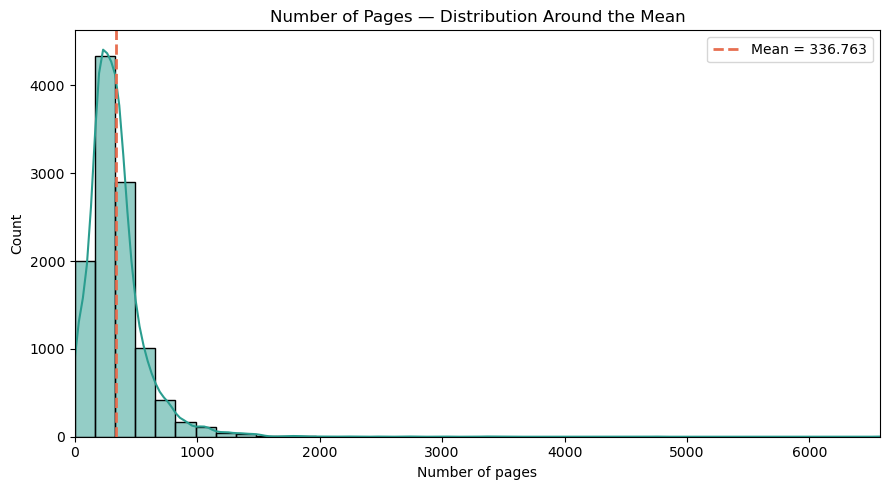

,metric,value
0,mean,336.762810
1,standard_deviation,240.971269
2,minimum,0.000000
3,maximum,6576.000000
4,count,11046.000000


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Number of Pages — Distribution Around the Mean'}, xlabel='Number of pages', ylabel='Count'>)

In [58]:
# num_pages
plot_distribution_with_mean(
    df_clean,
    column="num_pages",
    lower=0,
    upper=df_clean["num_pages"].max(),
    title="Number of Pages — Distribution Around the Mean",
    xlabel="Number of pages",
)

## Analysis : Language Codes
------------

In [59]:
language_value_counts = df_clean["language_code"].value_counts(dropna=False)
language_value_counts

language_code
eng      8847
en-US    1409
en-GB     214
spa       212
fre       140
ger        96
jpn        45
mul        19
zho        14
por        10
grc         9
en-CA       7
ita         5
enm         3
lat         3
swe         2
rus         2
nl          1
msa         1
glg         1
wel         1
ara         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64

In [60]:
lang_values = language_value_counts.index.to_list()
lang_values

['eng',
 'en-US',
 'en-GB',
 'spa',
 'fre',
 'ger',
 'jpn',
 'mul',
 'zho',
 'por',
 'grc',
 'en-CA',
 'ita',
 'enm',
 'lat',
 'swe',
 'rus',
 'nl',
 'msa',
 'glg',
 'wel',
 'ara',
 'nor',
 'tur',
 'gla',
 'ale']

In [64]:
# ── Language Code Cleaning ──────────────────────────────────────────────────

# 1. All English variants → "English"
english_codes = {"en-US", "en-GB", "eng", "en-CA", "en-AU", "en-NZ", "en"}

df_clean["language_code_clean"] = df_clean["language_code"].apply(
    lambda x: "en" if x in english_codes else x
)

# 2. Languages with fewer than 20 books → "Other Language"
lang_counts = df_clean["language_code_clean"].value_counts(dropna=False)
rare_languages = lang_counts[lang_counts < 20].index

df_clean["language_code_clean"] = df_clean["language_code_clean"].apply(
    lambda x: "Other Language" if x in rare_languages else x
)

# ── Verify the result ────────────────────────────────────────────────────────
print(df_clean["language_code_clean"].value_counts(dropna=False))

language_code_clean
en                10477
spa                 212
fre                 140
ger                  96
Other Language       76
jpn                  45
Name: count, dtype: int64


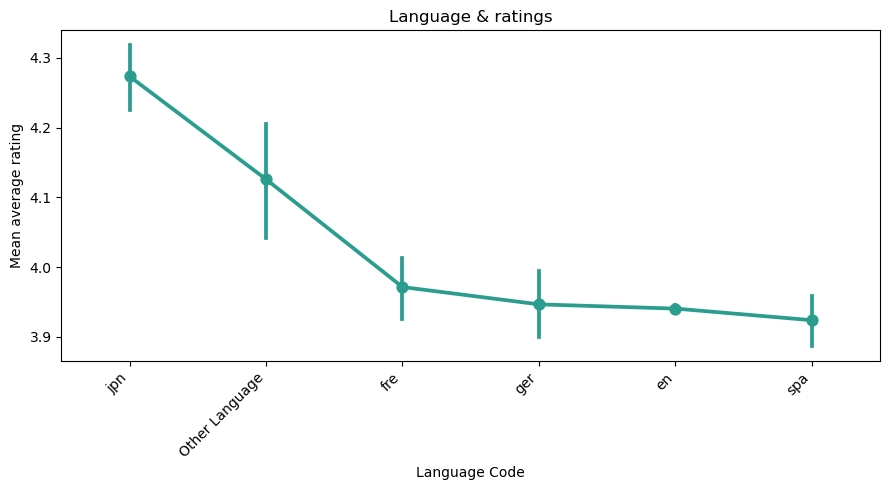

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))

language_value_counts = df_clean["language_code_clean"].value_counts(dropna=False)

language_plot = df_clean[["language_code_clean", "average_rating"]].copy()

order = (
    language_plot.groupby("language_code_clean", dropna=False)["average_rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.pointplot(
    data=language_plot,
    x="language_code_clean",
    y="average_rating",
    order=order,
    errorbar=("ci", 95),
    color="#2a9d8f",
    ax=ax,
)
ax.set_title("Language & ratings")
ax.set_xlabel("Language Code")
ax.set_ylabel("Mean average rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [67]:
# check for multi-language books
multi_lang = (
    df_clean.groupby(["title", "authors"])["language_code_clean"]
    .agg(n_languages="nunique", languages=lambda s: sorted(s.dropna().unique()))
    .reset_index()
    .query("n_languages > 1")
    .sort_values("n_languages", ascending=False)
    .head(50)
)
multi_lang

,title,authors,n_languages,languages
1313,carrie,stephen king,2,"[en, spa]"
2866,galapagos,kurt vonnegut jr.,2,"[en, fre]"
2950,glamorama,bret easton ellis,2,"[en, ger]"
4234,lincoln,gore vidal,2,"[en, spa]"
5437,pedro paramo,juan rulfo,2,"[ger, spa]"
5991,sahara (dirk pitt #11),clive cussler,2,"[en, spa]"
6271,siddhartha,hermann hesse,2,"[en, fre]"
6704,tar baby,toni morrison,2,"[en, fre]"
10121,v.,thomas pynchon,2,"[en, ger]"
